In [3]:
# Parquet dosyasından veriyi alıp pandas'a aktarma
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

table = pq.read_table('../data/nrel_data_5cities_2020_2024.parquet')

df = table.to_pandas()

print(df)

                     Year  Month  Day  Hour  Minute  GHI  DHI  DNI  \
datetime                                                             
2020-01-01 00:00:00  2020      1    1     0       0    0    0    0   
2020-01-01 00:30:00  2020      1    1     0      30    0    0    0   
2020-01-01 01:00:00  2020      1    1     1       0    0    0    0   
2020-01-01 01:30:00  2020      1    1     1      30    0    0    0   
2020-01-01 02:00:00  2020      1    1     2       0    0    0    0   
...                   ...    ...  ...   ...     ...  ...  ...  ...   
2024-12-31 21:30:00  2024     12   31    21      30    0    0    0   
2024-12-31 22:00:00  2024     12   31    22       0    0    0    0   
2024-12-31 22:30:00  2024     12   31    22      30    0    0    0   
2024-12-31 23:00:00  2024     12   31    23       0    0    0    0   
2024-12-31 23:30:00  2024     12   31    23      30    0    0    0   

                     Wind Speed  Temperature  Cloud Type  Dew Point  \
datetime          

Toplam Ham Satır: 438,000
Gündüz Satır Sayısı: 221,516


<Figure size 1200x600 with 0 Axes>

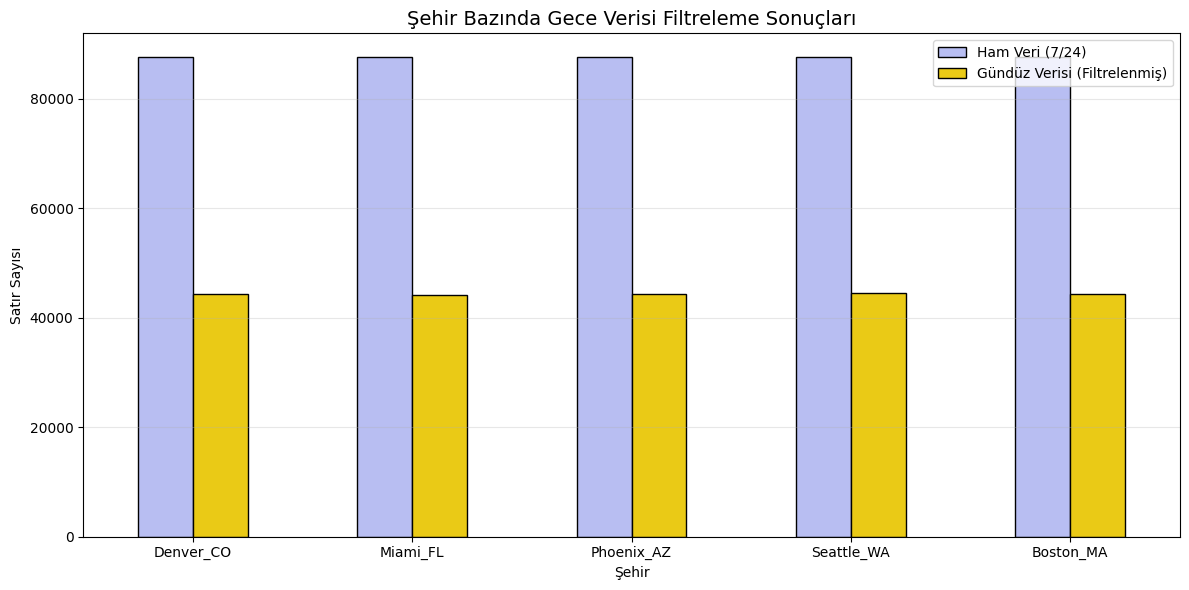

In [4]:
# Gece Körlüğü Filtrelemesi
# Geceleri güneş paneli üretim yapmayacağı için (GHI = 0) bunları modelde tutmak başarı oranının (RMSE) "sahte" şekilde 
# yüksek çıkmasına neden olur.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Gece Maskesi (Zenith > 90 veya GHI == 0)
night_mask = (df['Solar Zenith Angle'] > 90) | (df['GHI'] == 0)
day_df = df.loc[~night_mask].copy()

# Görselleştirme: Filtreleme Öncesi ve Sonrası Şehir Bazlı Dağılım
before_counts = df['City'].value_counts().rename('Ham Veri (7/24)')
after_counts = day_df['City'].value_counts().rename('Gündüz Verisi (Filtrelenmiş)')

compare_df = pd.concat([before_counts, after_counts], axis=1).reset_index()

plt.figure(figsize=(12, 6))
compare_df.plot(x='City', kind='bar', figsize=(12, 6), color=["#B8BEF2", "#eaca16"], edgecolor='black')
plt.title('Şehir Bazında Gece Verisi Filtreleme Sonuçları', fontsize=14)
plt.ylabel('Satır Sayısı')
plt.xlabel('Şehir')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend()


print(f"Toplam Ham Satır: {len(df):,}")
print(f"Gündüz Satır Sayısı: {len(day_df):,}")

plt.tight_layout()
plt.savefig('../outputs/plots/day_filtering_data_set.pdf')
plt.show()

/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_85710/1428900305.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_df, x='City', y='Clearness_Index', palette='Set3')


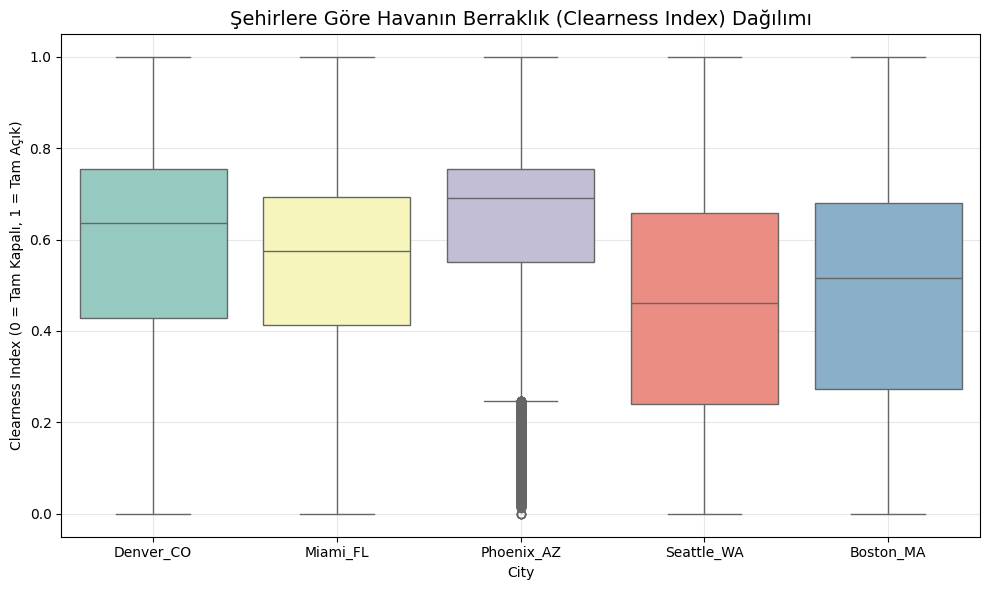

In [5]:
# Zaman Şifreleme ve Berraklık İndeksi Hesaplama
# Saatleri ve ayları modelin daha iyi öğrenebilmesi için sinüs ve kosinüs dönüşümleriyle zaman şifrelemesi yapacağız.
# Berraklık İndeksi (Clearness Index) ise GHI'nin, o anki güneş ışınımının teorik maksimumu olan extraterrestrial radiation'a oranıdır.
# Bu, havanın ne kadar açık veya kapalı olduğunu gösterir ve modelin hava durumunu anlamasına yardımcı olabilir.
 
# Time Encoding (Zaman Şifreleme)
day_df['hour_sin'] = np.sin(2 * np.pi * day_df.index.hour / 24.0)
day_df['hour_cos'] = np.cos(2 * np.pi * day_df.index.hour / 24.0)
day_df['month_sin'] = np.sin(2 * np.pi * day_df.index.month / 12.0)
day_df['month_cos'] = np.cos(2 * np.pi * day_df.index.month / 12.0)

# 2. Berraklık İndeksi (Clearness Index)
# Extraterrestrial Radiation sabiti: ~1367 W/m2
zenith_rad = np.radians(day_df['Solar Zenith Angle'])
extraterrestrial = 1367 * np.cos(zenith_rad)

# 0'a bölme hatasını önlemek için klipsleme yapıyoruz
day_df['Clearness_Index'] = (day_df['GHI'] / extraterrestrial.replace(0, np.nan)).clip(0, 1)

# Şehirlerin Berraklık Karşılaştırması (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=day_df, x='City', y='Clearness_Index', palette='Set3')
plt.title('Şehirlere Göre Havanın Berraklık (Clearness Index) Dağılımı', fontsize=14)
plt.ylabel('Clearness Index (0 = Tam Kapalı, 1 = Tam Açık)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/clearness_index.pdf')
plt.show()

/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_85710/4127768208.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=daily_table, x='City', y='std', palette='pastel', inner='quartile')


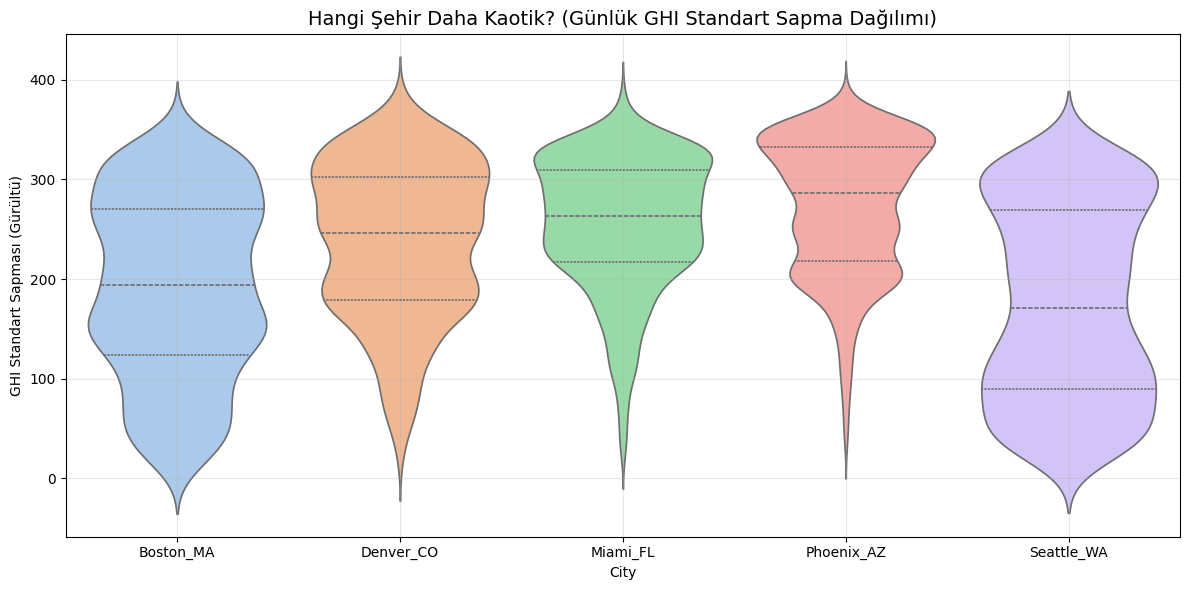

In [6]:
# Günlük Gürültü Skorunu Bulma (Daily Volatility)
# Her günü GHI bazında ortalama ve standart sapmasını bulan tablo oluşturma
# Günlük tablomuza City kolonunu da ekleyerek grupluyoruz
day_df['date'] = day_df.index.date
daily_table = day_df.groupby(['City', 'date'])['GHI'].agg(['mean', 'std']).dropna().reset_index()

# Şehirlerin Gürültü (Std) Karşılaştırması - Keman Grafiği (Violin Plot)
plt.figure(figsize=(12, 6))
sns.violinplot(data=daily_table, x='City', y='std', palette='pastel', inner='quartile')
plt.title('Hangi Şehir Daha Kaotik? (Günlük GHI Standart Sapma Dağılımı)', fontsize=14)
plt.ylabel('GHI Standart Sapması (Gürültü)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/daily_volatility.pdf')
plt.show()

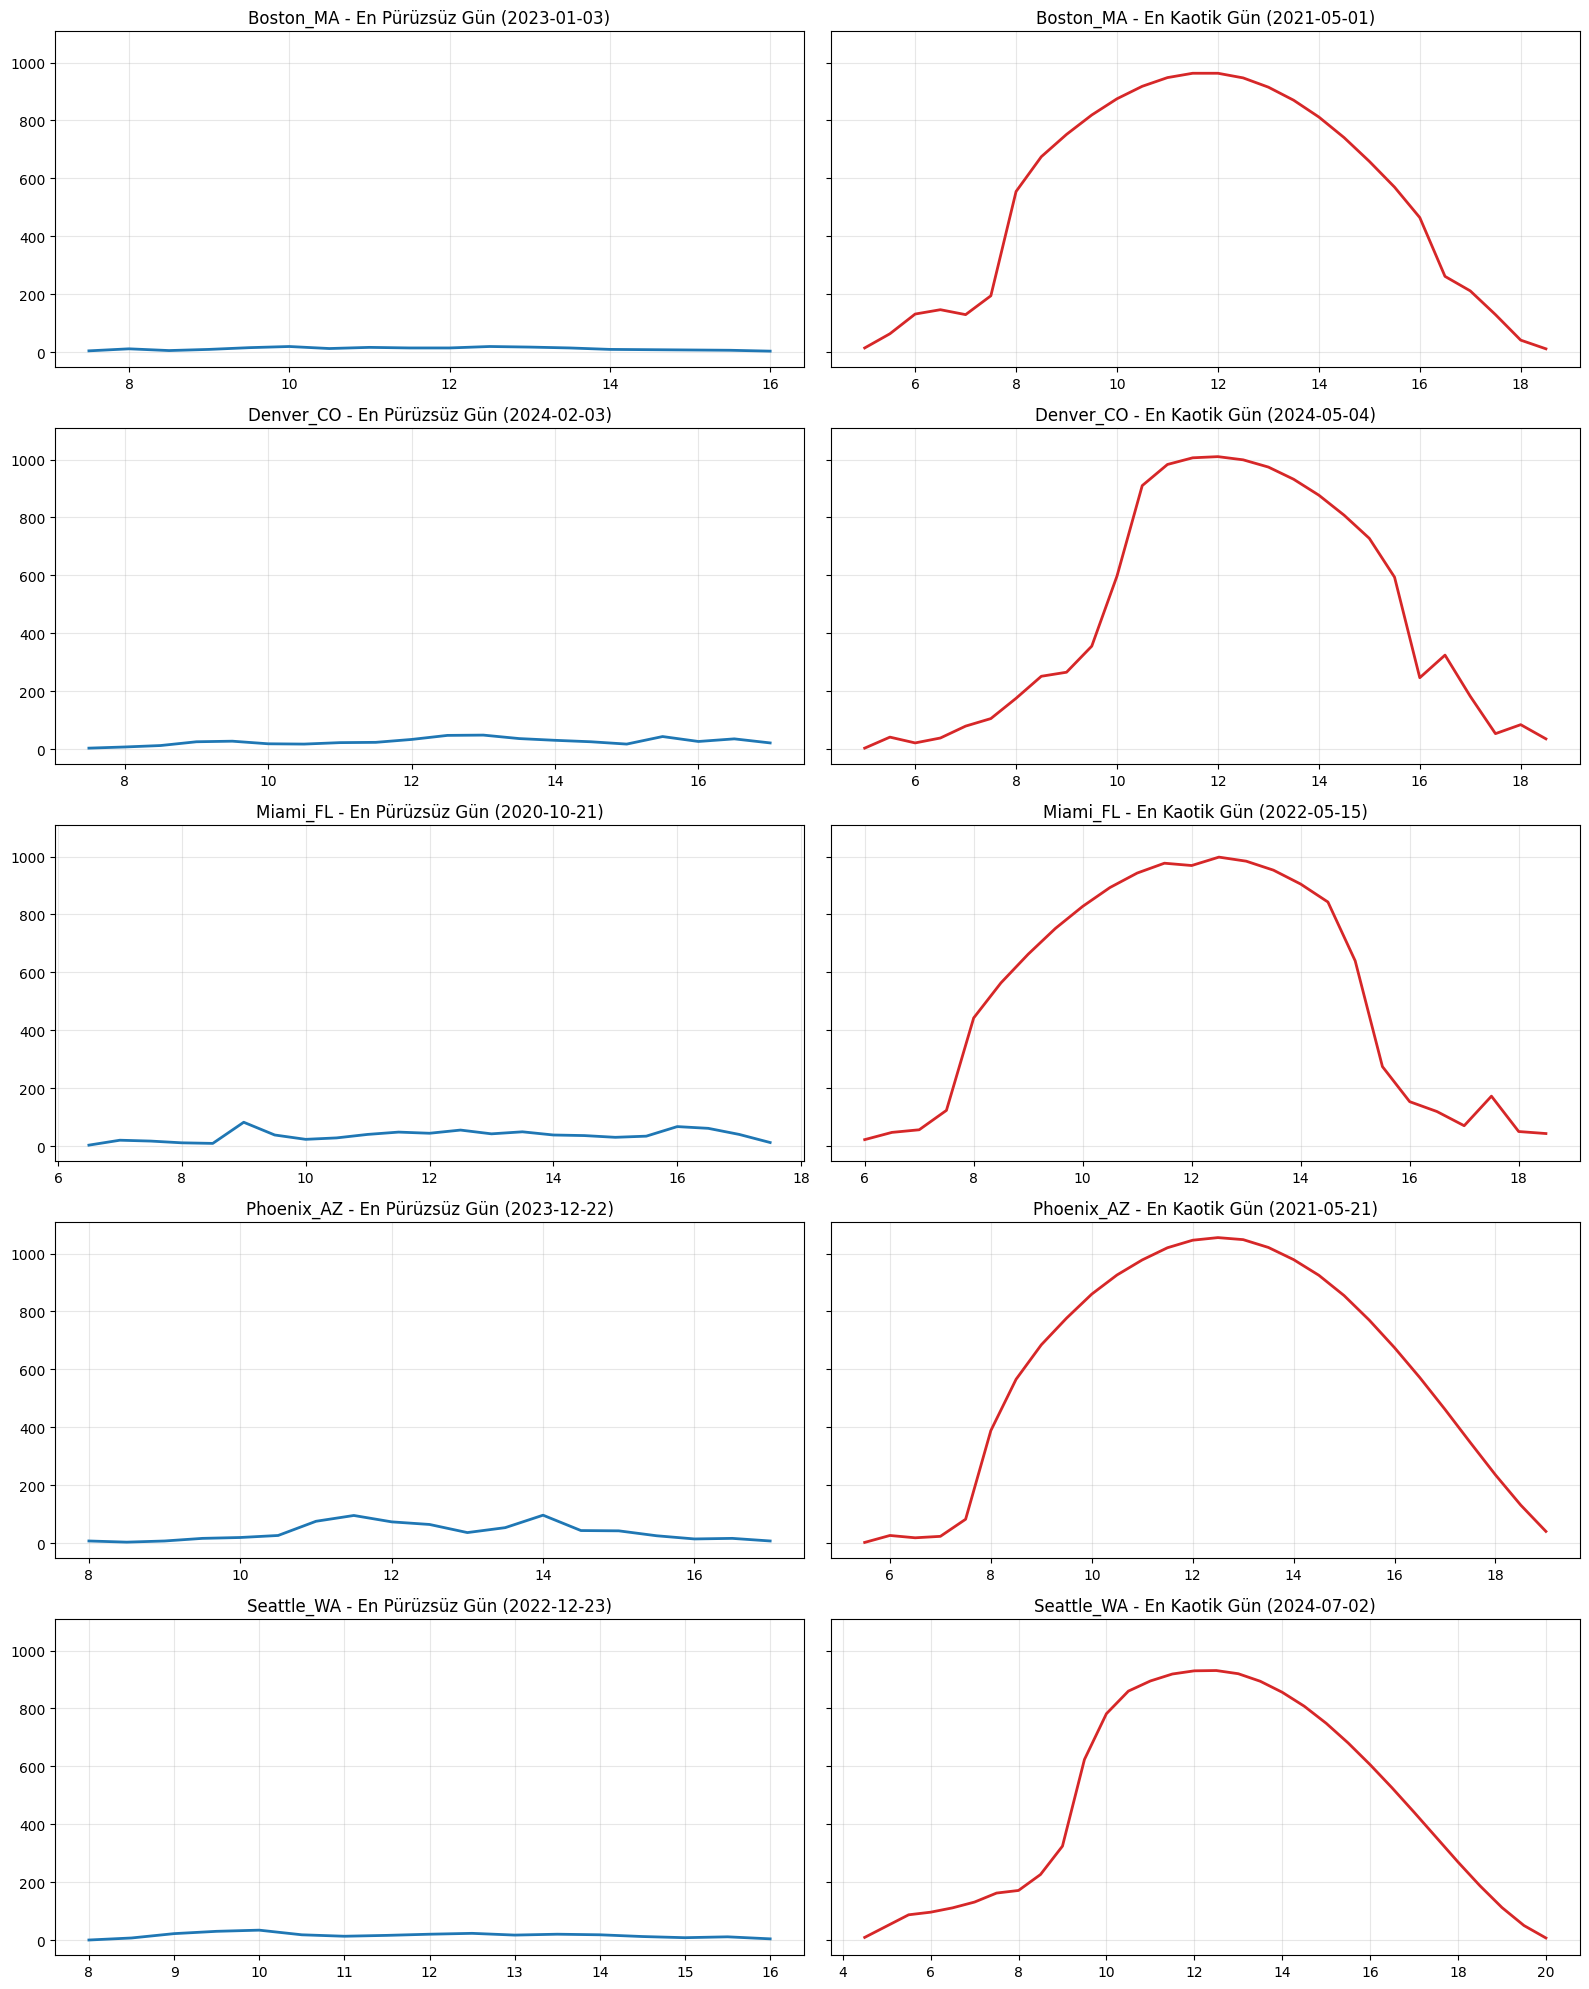

In [7]:
# En düşük çıkan yaz günü ile en yüksek çıkan bahar günün GHI karşılaştırması
cities = daily_table['City'].unique()
fig, axes = plt.subplots(len(cities), 2, figsize=(16, 4 * len(cities)), sharey=True)

for i, city in enumerate(cities):
    city_data = daily_table[daily_table['City'] == city]
    
    # En pürüzsüz ve en kaotik günleri bul
    smooth_date = city_data.loc[city_data['std'].idxmin(), 'date']
    chaotic_date = city_data.loc[city_data['std'].idxmax(), 'date']
    
    # Ham verileri çek
    smooth_ghi = day_df[(day_df['City'] == city) & (day_df['date'] == smooth_date)]['GHI']
    chaotic_ghi = day_df[(day_df['City'] == city) & (day_df['date'] == chaotic_date)]['GHI']
    
    # Çizim - Pürüzsüz
    axes[i, 0].plot(smooth_ghi.index.hour + smooth_ghi.index.minute/60, smooth_ghi.values, color='tab:blue', lw=2)
    axes[i, 0].set_title(f"{city} - En Pürüzsüz Gün ({smooth_date})")
    axes[i, 0].grid(alpha=0.3)
    
    # Çizim - Kaotik
    axes[i, 1].plot(chaotic_ghi.index.hour + chaotic_ghi.index.minute/60, chaotic_ghi.values, color='tab:red', lw=2)
    axes[i, 1].set_title(f"{city} - En Kaotik Gün ({chaotic_date})")
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/smooth_chaotic_ghi.pdf')
plt.show()

               mean         std
Cluster                        
2        133.948683   89.893076
0        339.869358  209.801537
1        515.161611  307.039539


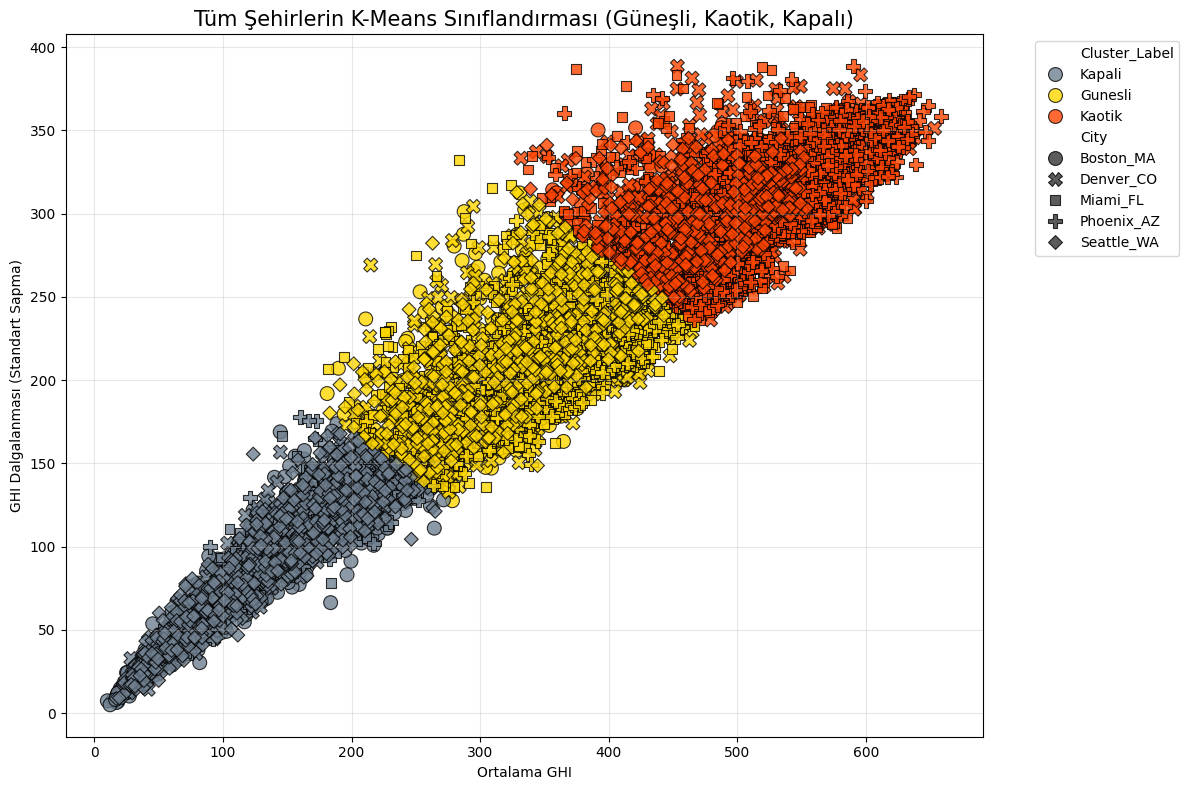

In [8]:
# Gorev 4: Feature Scaling (mean ve std'yi ayni olcege getir)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
scaled_features = scaler.fit_transform(daily_table[['mean', 'std']])

# Tüm şehirleri aynı modelde eğitiyoruz
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
daily_table['Cluster'] = kmeans.fit_predict(scaled_features)

# Dinamik İsimlendirme Mantığı
cluster_summary = daily_table.groupby('Cluster')[['mean', 'std']].mean().sort_values('mean')
label_map = {
    cluster_summary.index[0]: 'Kapali',
    cluster_summary['std'].idxmax(): 'Kaotik'
}
for c in cluster_summary.index:
    if c not in label_map:
        label_map[c] = 'Gunesli'

daily_table['Cluster_Label'] = daily_table['Cluster'].map(label_map)

# Daha Estetik Bir Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=daily_table, x='mean', y='std', 
    hue='Cluster_Label', style='City', 
    palette={'Gunesli': '#FFD700', 'Kaotik': '#FF4500', 'Kapali': '#708090'},
    s=100, alpha=0.8, edgecolor='black'
)

print(cluster_summary)
plt.title('Tüm Şehirlerin K-Means Sınıflandırması (Güneşli, Kaotik, Kapalı)', fontsize=15)
plt.xlabel('Ortalama GHI')
plt.ylabel('GHI Dalgalanması (Standart Sapma)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/kmeans_clusters.pdf')
plt.show()

daily_table.to_csv('../outputs/reports/daily_clusters.csv', index=True)


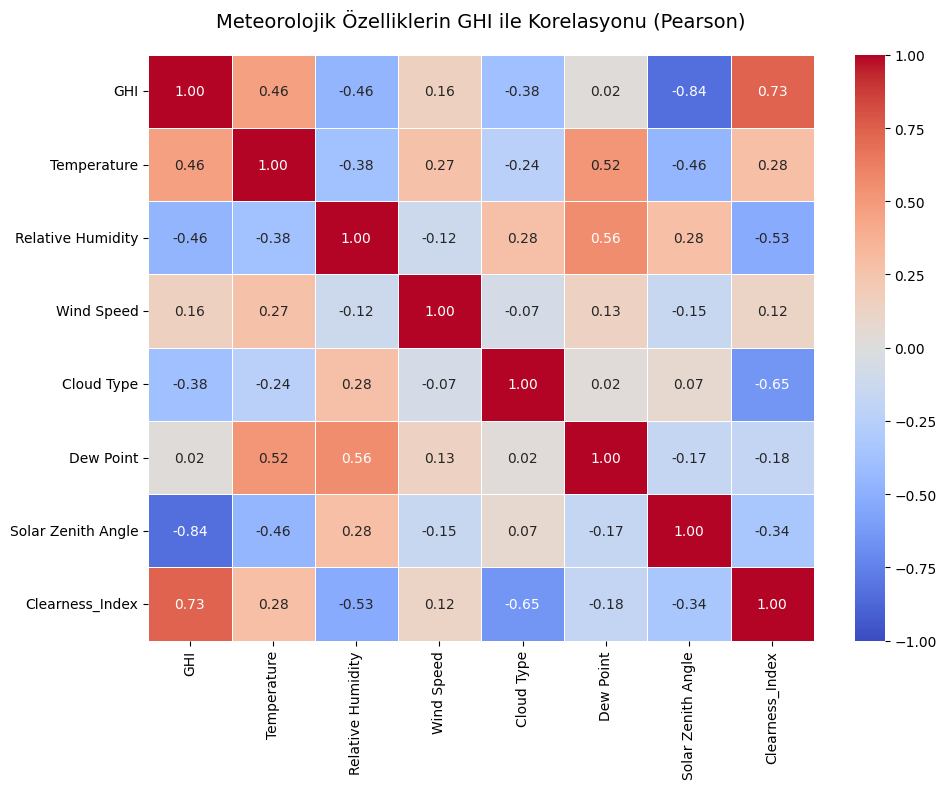

In [9]:
# 1. Analiz edilecek özellikleri seçelim
corr_cols = [
    'GHI', 'Temperature', 'Relative Humidity', 'Wind Speed', 
    'Cloud Type', 'Dew Point', 'Solar Zenith Angle', 'Clearness_Index'
]

# 2. Korelasyon Matrisini Hesapla
corr_matrix = day_df[corr_cols].corr()

# 3. Isı Haritası (Heatmap) Çizimi
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Kutu içlerine rakamları yaz
    cmap='coolwarm',     # Kırmızı-Mavi renk skalası (Sıcak/Soğuk)
    fmt=".2f",           # Virgülden sonra 2 hane
    vmin=-1, vmax=1,     # Skalanın sınırları (-1 ters orantı, 1 doğru orantı)
    linewidths=0.5
)
plt.title('Meteorolojik Özelliklerin GHI ile Korelasyonu (Pearson)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../outputs/plots/heatmap.pdf')
plt.show()


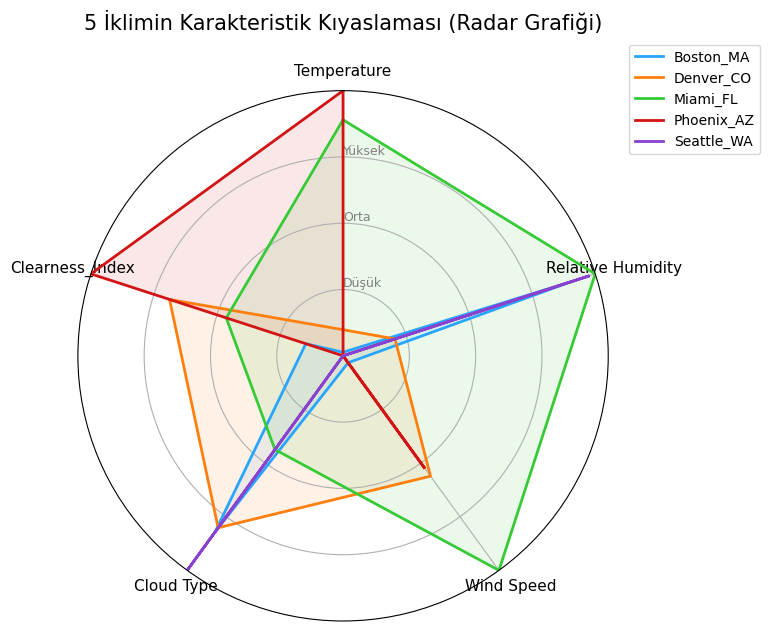

In [10]:
from sklearn.preprocessing import MinMaxScaler
from math import pi
import pandas as pd

# 1. İncelenecek özellikleri seç ve şehir bazında ortalamalarını al
radar_cols = ['Temperature', 'Relative Humidity', 'Wind Speed', 'Cloud Type', 'Clearness_Index']
city_means = day_df.groupby('City')[radar_cols].mean()

# 2. Verileri 0-1 arasına sıkıştır (Normalize et) ki aynı grafiğe sığsınlar
scaler_radar = MinMaxScaler()
city_means_scaled = pd.DataFrame(
    scaler_radar.fit_transform(city_means), 
    index=city_means.index, 
    columns=radar_cols
)

# 3. Radar Grafiği Matematiksel Hazırlığı (Açılar)
categories = list(city_means_scaled.columns)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Daireyi kapatmak için ilk açıyı sona ekle

# 4. Çizim İşlemleri
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(pi / 2) # Başlangıcı tepeye al
ax.set_theta_direction(-1)  # Saat yönünde çiz

# Eksen ayarları
plt.xticks(angles[:-1], categories, size=11)
ax.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75], ["Düşük", "Orta", "Yüksek"], color="grey", size=9)
plt.ylim(0, 1)

# Şehirleri sırayla grafiğe ekle
colors = ["#28a5ff", '#ff7f0e', "#37ca37", "#d31414", "#8a42ce"]
for idx, (city_name, row) in enumerate(city_means_scaled.iterrows()):
    values = row.tolist()
    values += values[:1] # Daireyi kapat
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=city_name, color=colors[idx])
    ax.fill(angles, values, color=colors[idx], alpha=0.1) # İçini hafifçe boya

plt.title('5 İklimin Karakteristik Kıyaslaması (Radar Grafiği)', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../outputs/plots/radar_grafic.pdf')
plt.show()

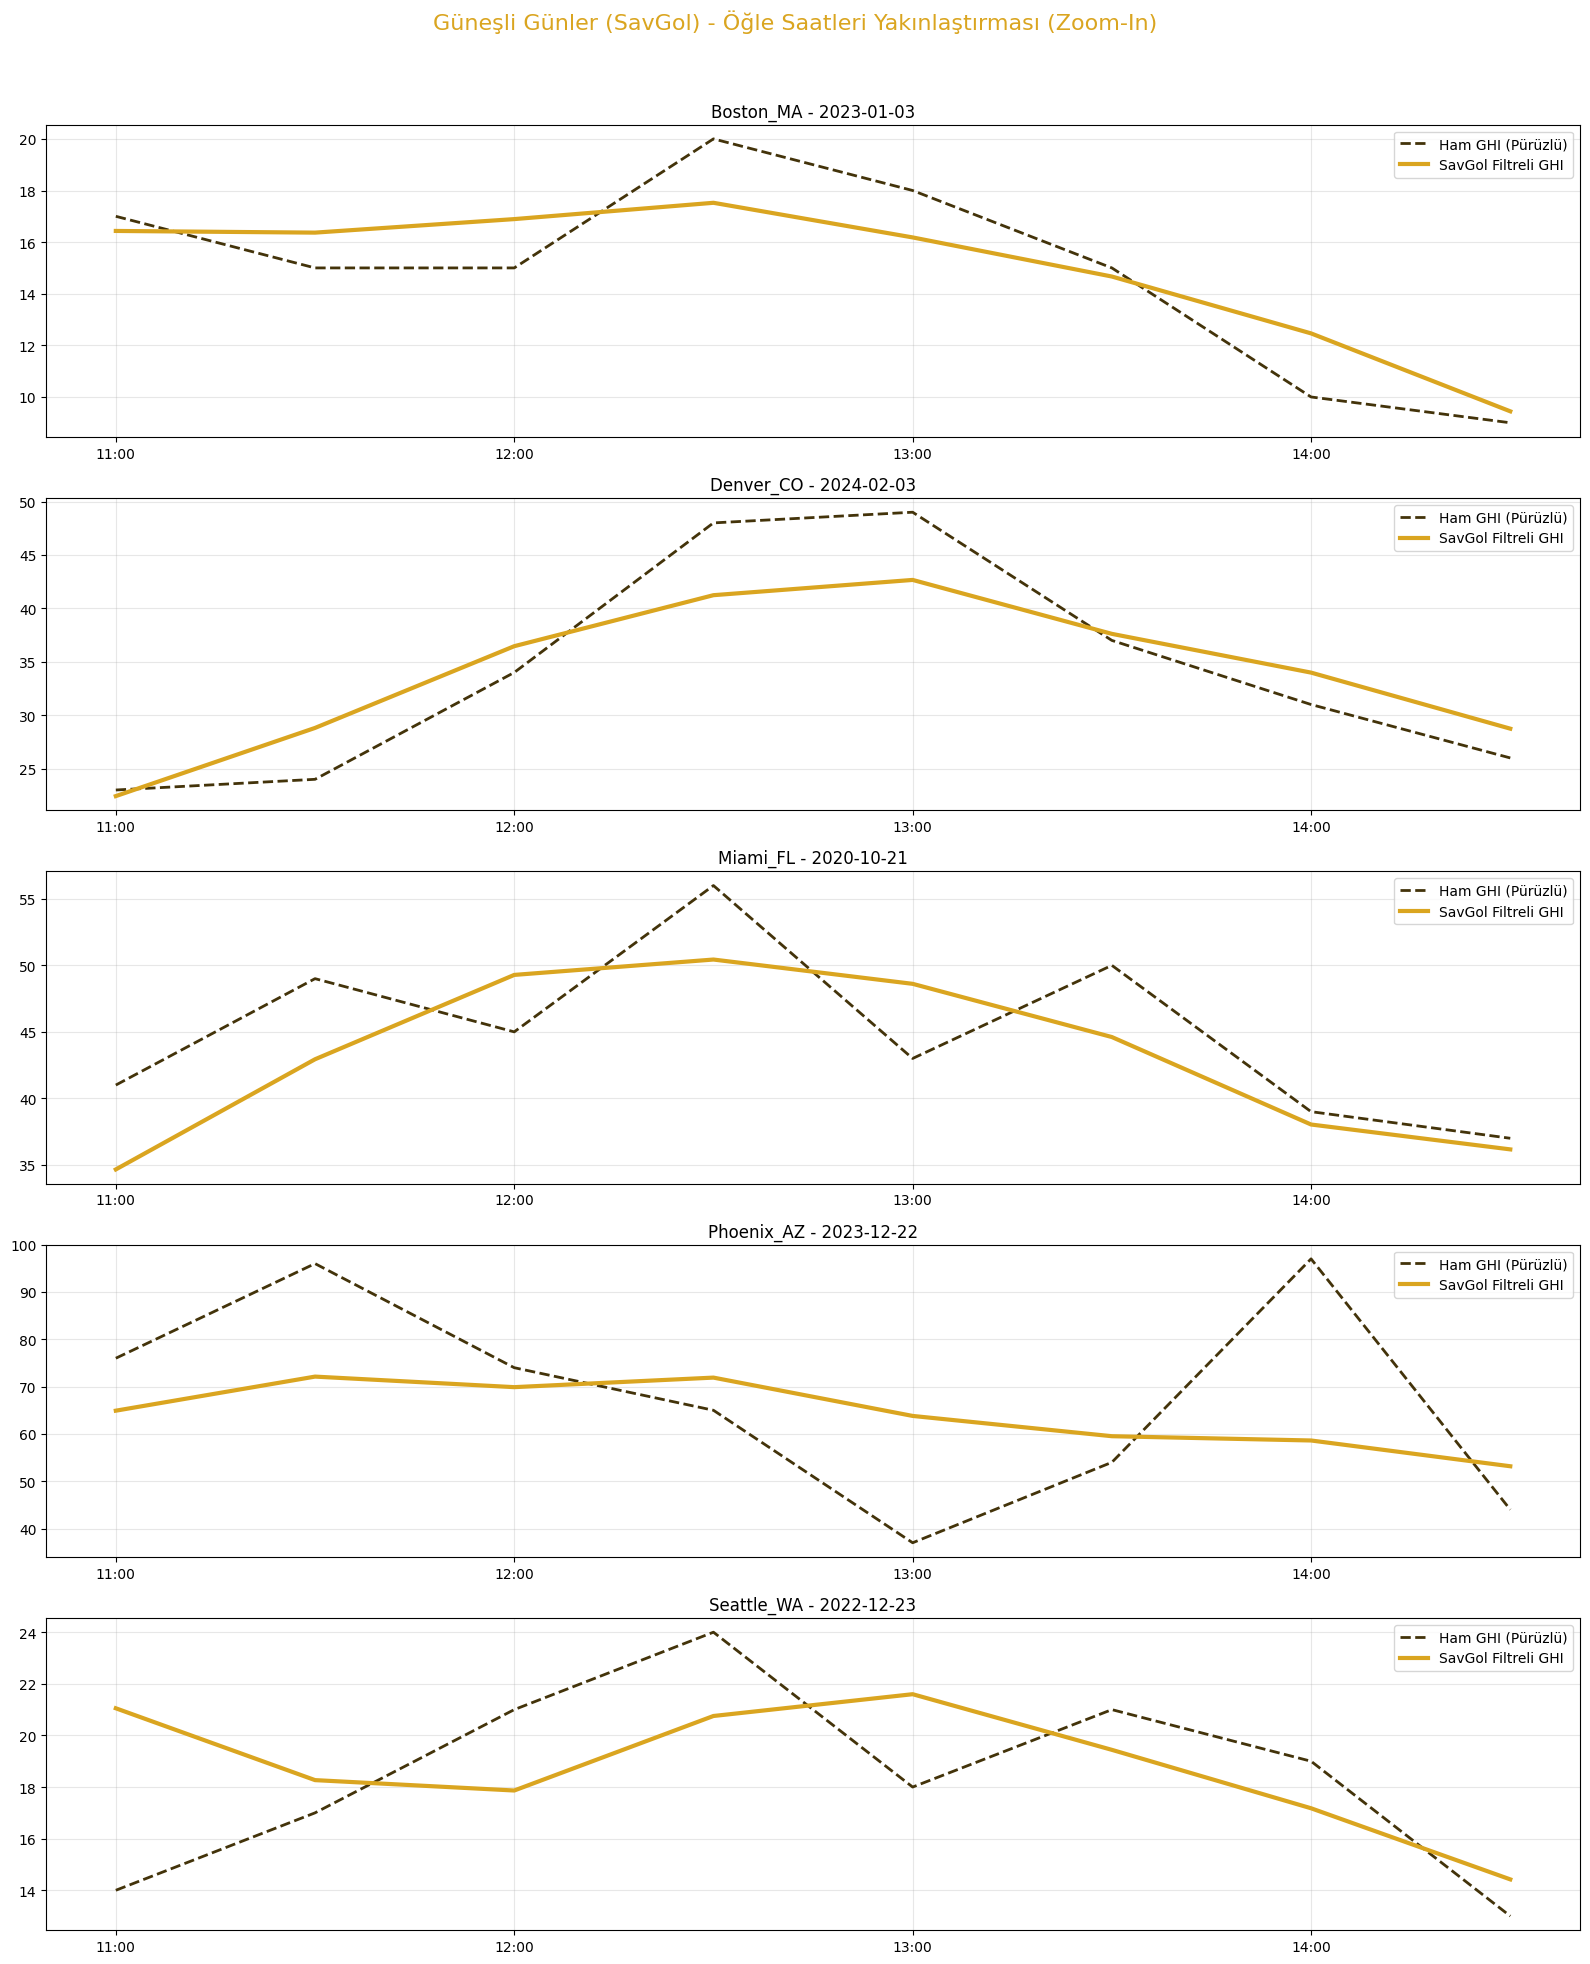

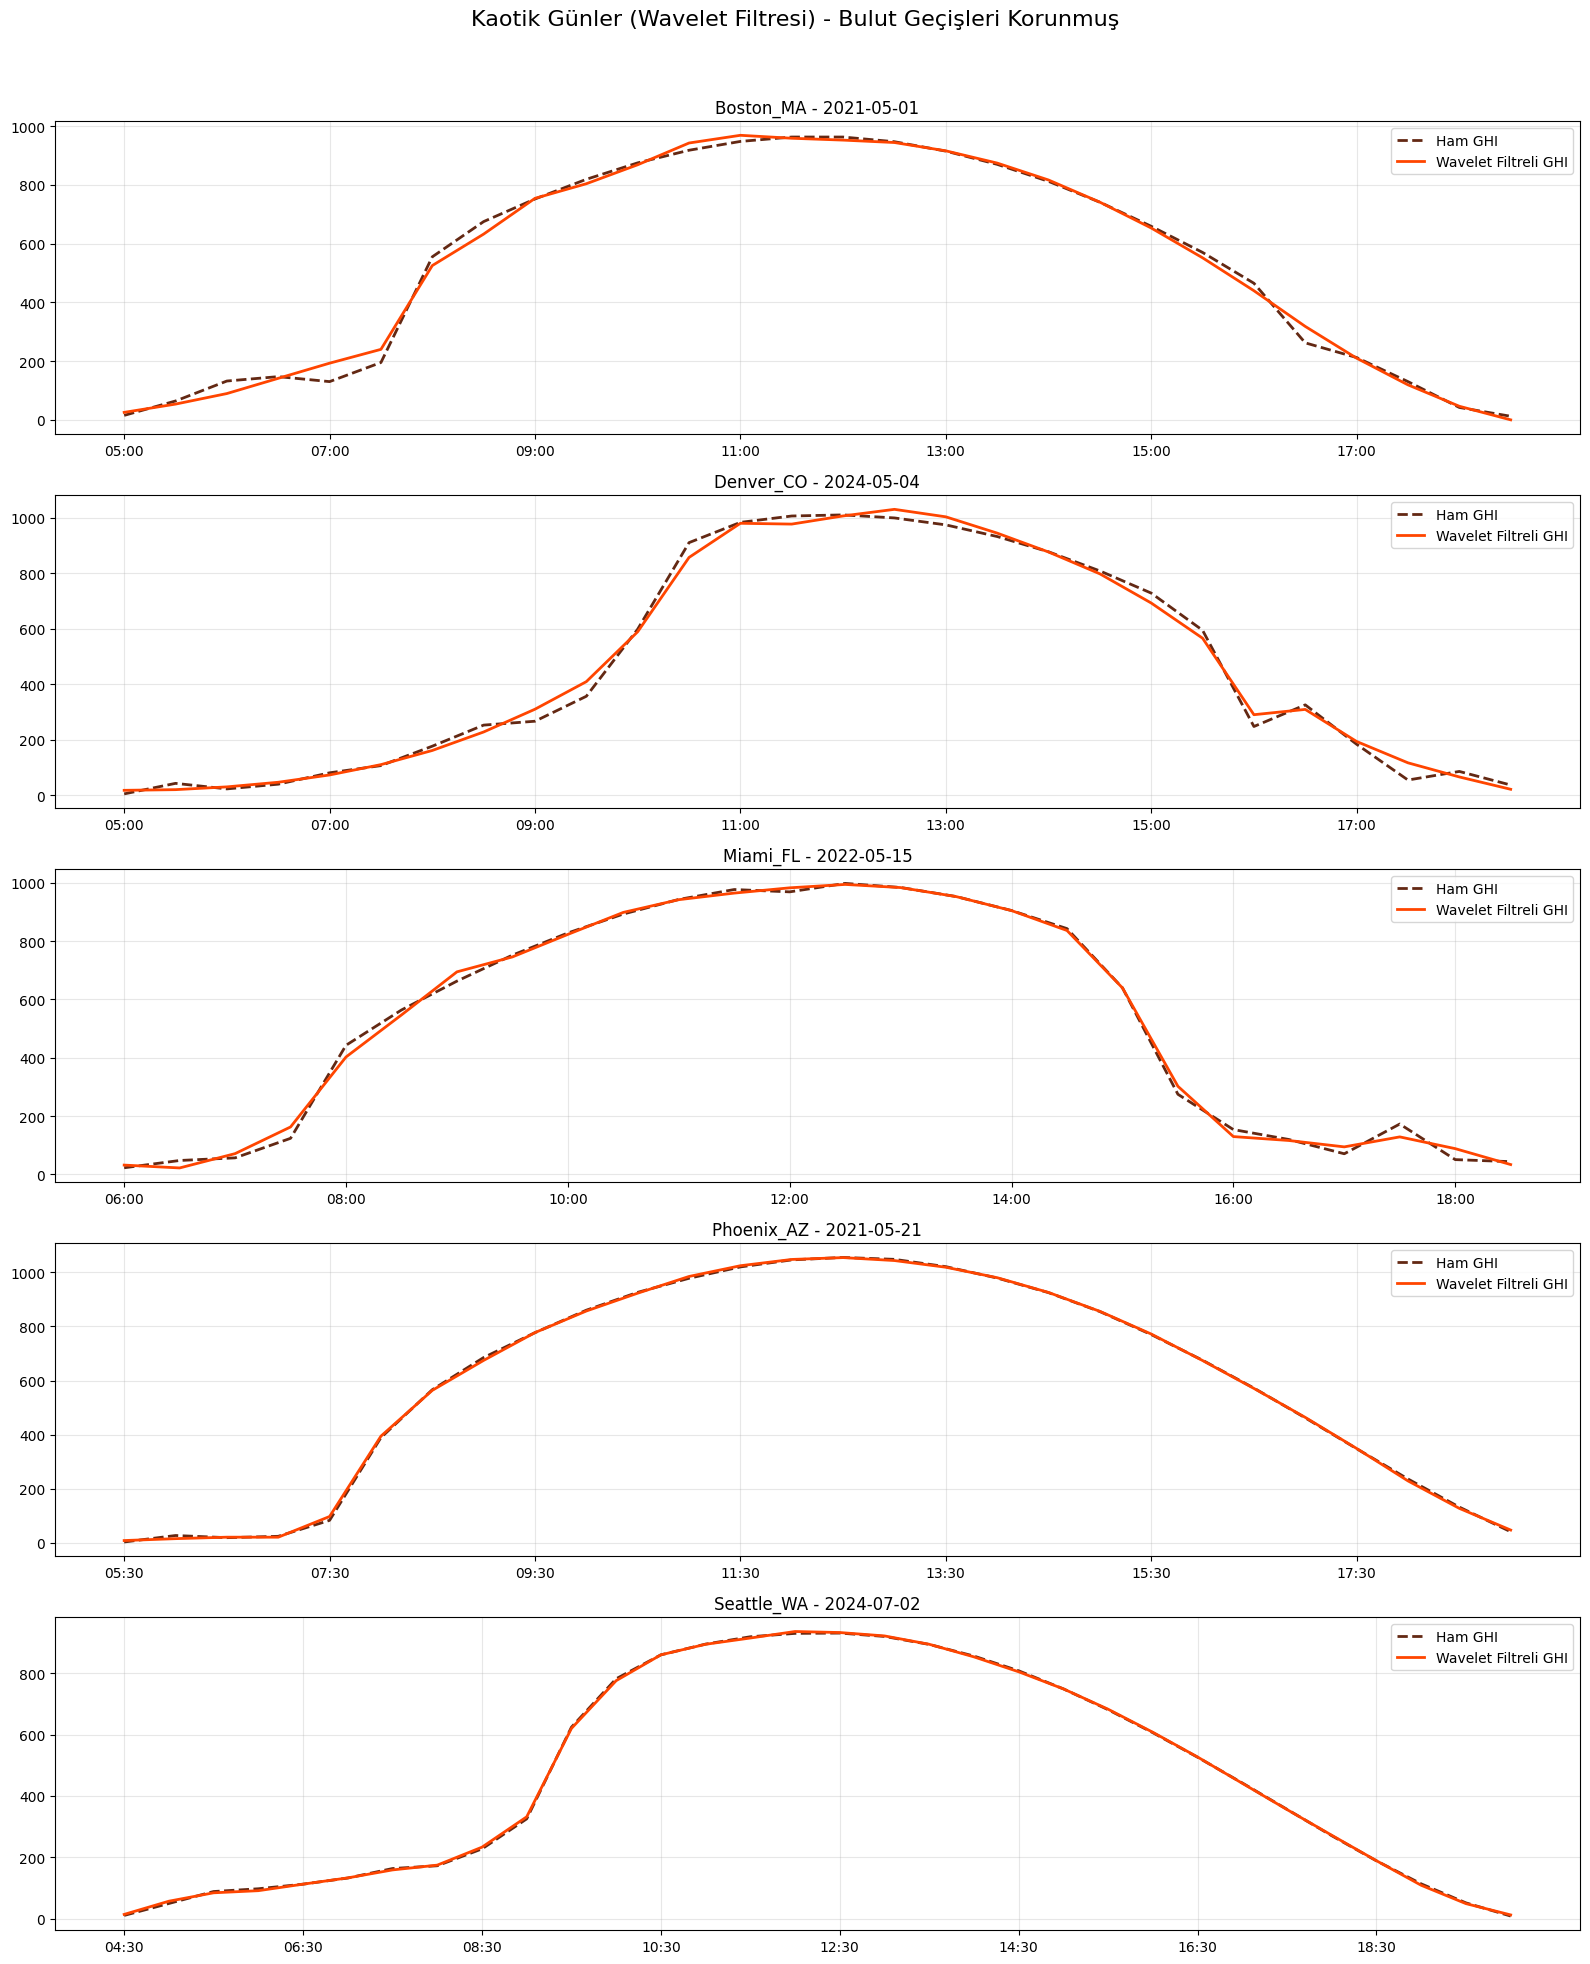

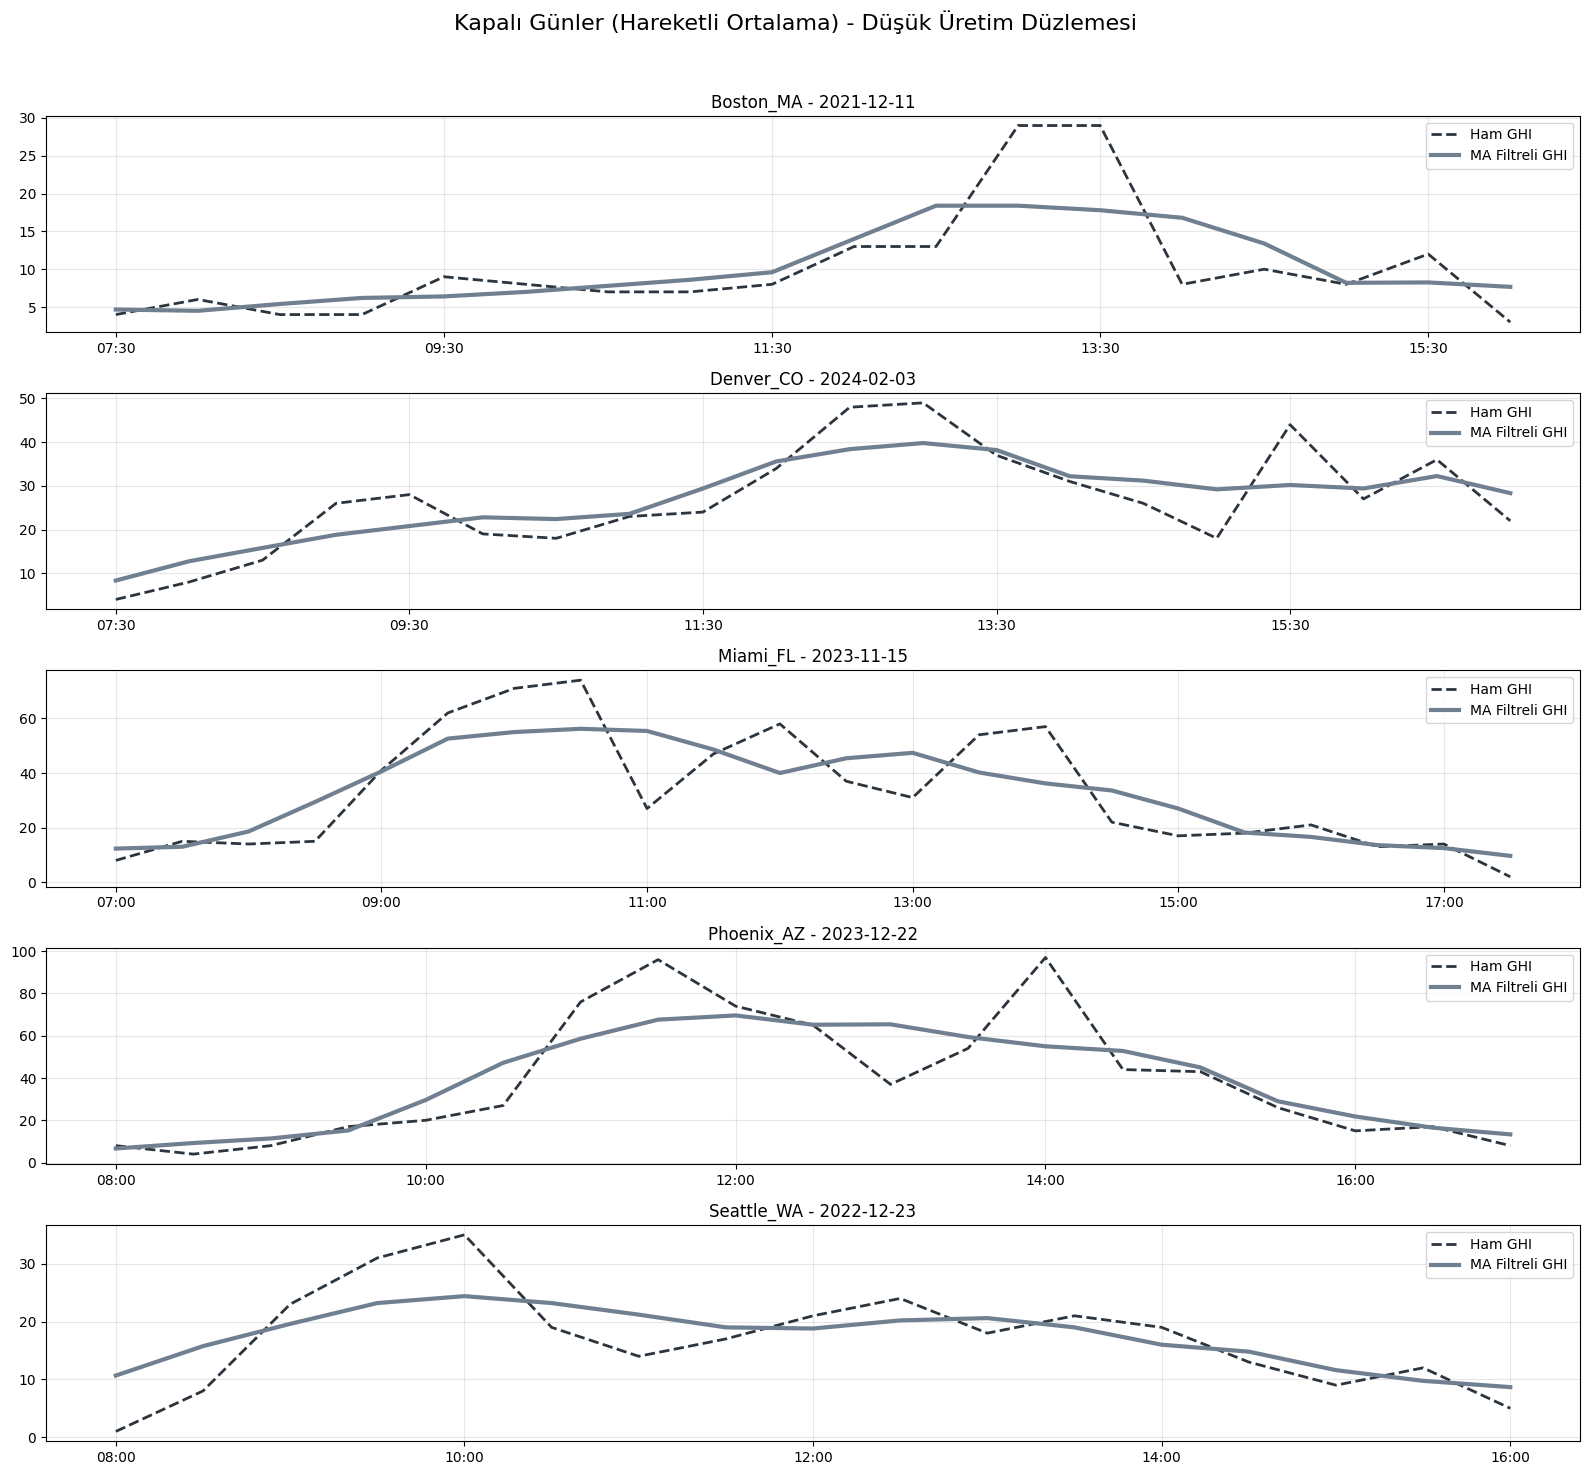

In [11]:
import sys
import os
import matplotlib.pyplot as plt

# Filtrelerimizi kendi modülümüzden çağırıyoruz
project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src.filters import sav_gol_filter, wavelet_filter, mov_avg_filter

cities = daily_table['City'].unique()

# ==========================================
# ŞEKİL 1: GÜNEŞLİ GÜNLER (SavGol Filtresi)
# ==========================================
fig1, axes1 = plt.subplots(len(cities), 1, figsize=(16, 4*len(cities)), sharex=False)
# y=1.01 kısmını siliyoruz veya y=0.98 yapıyoruz (içeride kalsın diye)
fig1.suptitle("Güneşli Günler (SavGol) - Öğle Saatleri Yakınlaştırması (Zoom-In)", fontsize=16, color='#DAA520', y=0.98)


for i, city in enumerate(cities):
    city_data = daily_table[daily_table['City'] == city]
    sunny_date = city_data.loc[city_data['std'].idxmin(), 'date'] # En pürüzsüz gün
    
    city_day_data = day_df[(day_df['City'] == city) & (day_df['date'] == sunny_date)]
    filtered_ghi = sav_gol_filter(city_day_data['GHI'].values, window_length=9, polyorder=3)
    
    # Zoom işlemi: Sadece 11 ve 14 saatleri arasını al
    zoom_mask = (city_day_data.index.hour >= 11) & (city_day_data.index.hour <= 14)
    x_zoom = city_day_data[zoom_mask].index.time
    x_strs = [t.strftime("%H:%M") for t in x_zoom]
    
    axes1[i].plot(x_strs, city_day_data[zoom_mask]['GHI'].values, color="#43330A", lw=2, linestyle='--', label='Ham GHI (Pürüzlü)')
    axes1[i].plot(x_strs, filtered_ghi[zoom_mask], color='#DAA520', lw=3, label='SavGol Filtreli GHI')
    axes1[i].set_title(f"{city} - {sunny_date}")
    axes1[i].grid(alpha=0.3)
    axes1[i].legend(loc='upper right')
    axes1[i].set_xticks(x_strs[::2]) # X eksenini sıkışmaması için seyrelt

# tight_layout'a üstten %4'lük bir boşluk (0.96) bırakmasını söylüyoruz
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../outputs/plots/filtered_sunny_day_type.pdf', bbox_inches ='tight')
plt.show()

# ==========================================
# ŞEKİL 2: KAOTİK GÜNLER (Wavelet Filtresi)
# ==========================================
fig2, axes2 = plt.subplots(len(cities), 1, figsize=(16, 4*len(cities)), sharex=False)
fig2.suptitle("Kaotik Günler (Wavelet Filtresi) - Bulut Geçişleri Korunmuş", fontsize=16, color="#000000", y=0.98)

for i, city in enumerate(cities):
    city_data = daily_table[daily_table['City'] == city]
    chaotic_date = city_data.loc[city_data['std'].idxmax(), 'date'] # En dalgalı gün
    
    city_day_data = day_df[(day_df['City'] == city) & (day_df['date'] == chaotic_date)]
    filtered_ghi = wavelet_filter(city_day_data['GHI'].values, wavelet="db4", level=2)
    
    x_strs = [t.strftime("%H:%M") for t in city_day_data.index.time]
    
    axes2[i].plot(x_strs, city_day_data['GHI'].values, color="#632813", lw=2, linestyle='--', label='Ham GHI')
    axes2[i].plot(x_strs, filtered_ghi, color='#FF4500', lw=2, label='Wavelet Filtreli GHI')
    axes2[i].set_title(f"{city} - {chaotic_date}")
    axes2[i].grid(alpha=0.3)
    axes2[i].legend(loc='upper right')
    axes2[i].set_xticks(x_strs[::4])

# tight_layout'a üstten %4'lük bir boşluk (0.96) bırakmasını söylüyoruz
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../outputs/plots/filtered_closed_day_type.pdf',bbox_inches = 'tight')
plt.show()

# ==========================================
# ŞEKİL 3: KAPALI GÜNLER (Hareketli Ortalama)
# ==========================================
fig3, axes3 = plt.subplots(len(cities), 1, figsize=(16, 3*len(cities)), sharex=False)
fig3.suptitle("Kapalı Günler (Hareketli Ortalama) - Düşük Üretim Düzlemesi", fontsize=16, color="#000000", y=0.98)


for i, city in enumerate(cities):
    city_data = daily_table[daily_table['City'] == city]
    closed_date = city_data.loc[city_data['mean'].idxmin(), 'date'] # Ortalama üretimi en düşük gün
    
    city_day_data = day_df[(day_df['City'] == city) & (day_df['date'] == closed_date)]
    filtered_ghi = mov_avg_filter(city_day_data['GHI'].values, window=5, center=True)
    
    x_strs = [t.strftime("%H:%M") for t in city_day_data.index.time]
    
    axes3[i].plot(x_strs, city_day_data['GHI'].values, color="#2C353D", lw=2, linestyle='--', label='Ham GHI')
    axes3[i].plot(x_strs, filtered_ghi, color='#708090', lw=3, label='MA Filtreli GHI')
    axes3[i].set_title(f"{city} - {closed_date}")
    axes3[i].grid(alpha=0.3)
    axes3[i].legend(loc='upper right')
    axes3[i].set_xticks(x_strs[::4])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../outputs/plots/filtered_chaotic_day_type.pdf',bbox_inches = 'tight')
plt.show()

In [12]:
import os
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

# Filtre uygulayıcı fonksiyonumuzu çağırıyoruz
from src.filters import apply_filter_by_label

print("1. Etiketler ana tabloya (day_df) eşleniyor...")

# Önceki hatalı sütunlar kalmışsa temizleyelim
if 'Cluster_Label' in day_df.columns:
    day_df.drop(columns=['Cluster_Label'], inplace=True)
if 'GHI_Filtered' in day_df.columns:
    day_df.drop(columns=['GHI_Filtered'], inplace=True)

# MÜHENDİSLİK ÇÖZÜMÜ: Index'i sıfırlıyoruz. Artık her satırın 0, 1, 2 gibi eşsiz bir ID'si var.
# datetime bilgisi kaybolmuyor, normal bir sütun olarak tabloya katılıyor.
day_df = day_df.reset_index()

# Etiketleri birleştir
mapping_df = daily_table[['City', 'date', 'Cluster_Label']]
day_df = day_df.merge(mapping_df, on=['City', 'date'], how='left')

print("2. Her gün için Adaptif Filtreleme işlemi başlatılıyor (Bu işlem birkaç dakika sürebilir)...")
day_df['GHI_Filtered'] = np.nan

# Veriyi Şehir ve Gün bazında gruplayıp döngüye sokuyoruz
grouped = day_df.groupby(['City', 'date'])

for (city, date), group in grouped:
    label = group['Cluster_Label'].iloc[0]
    
    # Herhangi bir sebepten etiketsiz gün varsa ham veriyi olduğu gibi bırak
    if pd.isna(label):
        day_df.loc[group.index, 'GHI_Filtered'] = group['GHI']
        continue
        
    # İlgili güne ve etikete uygun filtreyi uygula
    filtered_signal = apply_filter_by_label(
        signal=group['GHI'].values,
        label=label,
        savgol_window=9,
        savgol_polyorder=3,
        wavelet_name='db4',
        wavelet_level=2,
        wavelet_threshold_scale=0.8,
        moving_window=5
    )
    
    # group.index artık 0, 1, 2 gibi eşsiz sayılar olduğu için çakışma yaşanmayacak!
    day_df.loc[group.index, 'GHI_Filtered'] = filtered_signal

print("3. İşlem tamamlandı! Parquet formatında kaydediliyor...")
# İşlem bitince datetime'ı tekrar ait olduğu yere, index'e alıyoruz
day_df.set_index('datetime', inplace=True)

os.makedirs('../data/processed', exist_ok=True)
save_path = '../data/processed/nrel_data_5cities_filtered.parquet'

table = pa.Table.from_pandas(day_df)
pq.write_table(table, save_path)

print(f"Tüm filtreler uygulandı! Veri seti başarıyla mühürlendi:\n -> {save_path}")

# Hızlı bir kontrol
print("\nÖrnek Çıktı (Ham vs Filtrelenmiş):")
print(day_df[['City', 'Cluster_Label', 'GHI', 'GHI_Filtered']].head())

1. Etiketler ana tabloya (day_df) eşleniyor...
2. Her gün için Adaptif Filtreleme işlemi başlatılıyor (Bu işlem birkaç dakika sürebilir)...
3. İşlem tamamlandı! Parquet formatında kaydediliyor...
Tüm filtreler uygulandı! Veri seti başarıyla mühürlendi:
 -> ../data/processed/nrel_data_5cities_filtered.parquet

Örnek Çıktı (Ham vs Filtrelenmiş):
                          City Cluster_Label  GHI  GHI_Filtered
datetime                                                       
2020-01-01 07:30:00  Denver_CO        Kapali    5          57.0
2020-01-01 08:00:00  Denver_CO        Kapali   38          90.0
2020-01-01 08:30:00  Denver_CO        Kapali  128         122.8
2020-01-01 09:00:00  Denver_CO        Kapali  189         137.0
2020-01-01 09:30:00  Denver_CO        Kapali  254         149.2
